Can we trust this data before analysis?

In [1]:
import pandas as pd

loan_df = pd.read_csv("/Users/purvapradippatil/prep/Credit-Risk-Portfolio-Analytics/data/processed/loan_selected_columns.csv")

loan_df.head()



,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,purpose,dti,revol_util,fico_range_low,fico_range_high,issue_d,addr_state,loan_status
0,3600.0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,debt_consolidation,5.91,29.7,675.0,679.0,Dec-2015,PA,Fully Paid
1,24700.0,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,small_business,16.06,19.2,715.0,719.0,Dec-2015,SD,Fully Paid
2,20000.0,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,home_improvement,10.78,56.2,695.0,699.0,Dec-2015,IL,Fully Paid
3,35000.0,35000.0,60 months,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,debt_consolidation,17.06,11.6,785.0,789.0,Dec-2015,NJ,Current
4,10400.0,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,major_purchase,25.37,64.5,695.0,699.0,Dec-2015,PA,Fully Paid


Step 1: Check Data Types

In [2]:
loan_df.dtypes

loan_amnt          float64
funded_amnt        float64
term                   str
int_rate           float64
installment        float64
grade                  str
sub_grade              str
emp_length             str
home_ownership         str
annual_inc         float64
purpose                str
dti                float64
revol_util         float64
fico_range_low     float64
fico_range_high    float64
issue_d                str
addr_state             str
loan_status            str
dtype: object

Step 2: Missing Value Analysis

In [3]:
missing = (
    loan_df.isnull()
           .sum()
           .sort_values(ascending=False)
)

missing

emp_length         146940
revol_util           1835
dti                  1744
annual_inc             37
purpose                33
addr_state             33
issue_d                33
fico_range_high        33
fico_range_low         33
loan_amnt              33
funded_amnt            33
home_ownership         33
sub_grade              33
grade                  33
installment            33
int_rate               33
term                   33
loan_status            33
dtype: int64

In [5]:
missing_df = pd.DataFrame({
    "Missing Count": loan_df.isnull().sum(),
    "Missing %": round((loan_df.isnull().sum()/len(loan_df))*100,2)
})

missing_df.sort_values("Missing %", ascending=False)

,Missing Count,Missing %
emp_length,146940,6.50
revol_util,1835,0.08
dti,1744,0.08
loan_amnt,33,0.00
purpose,33,0.00
addr_state,33,0.00
issue_d,33,0.00
fico_range_high,33,0.00
fico_range_low,33,0.00
annual_inc,37,0.00


Step 3: Visualize Missing Values

Matplotlib is building the font cache; this may take a moment.


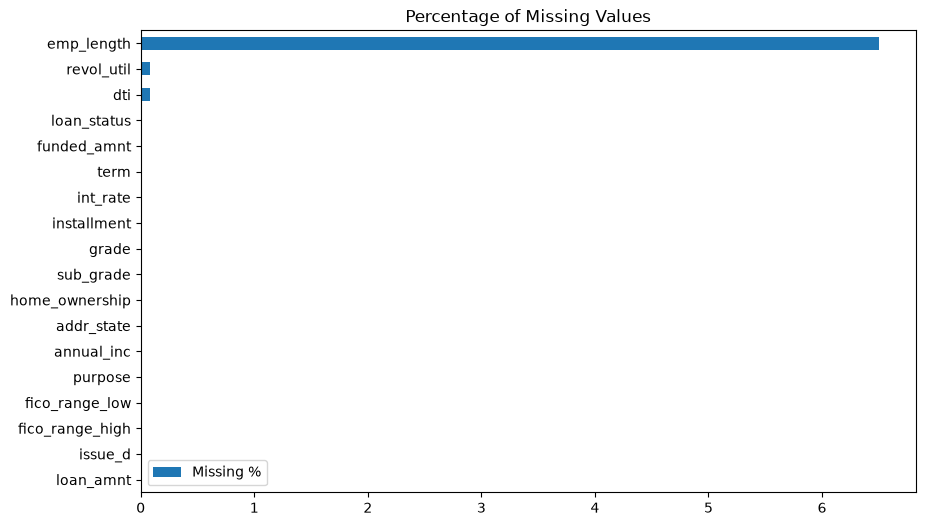

In [6]:
import matplotlib.pyplot as plt

missing_df.sort_values("Missing %").plot(
    y="Missing %",
    kind="barh",
    figsize=(10,6)
)

plt.title("Percentage of Missing Values")
plt.show()

Step 4: Check Duplicate Rows

In [7]:
loan_df.duplicated().sum()
loan_df[loan_df.duplicated()]

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,purpose,dti,revol_util,fico_range_low,fico_range_high,issue_d,addr_state,loan_status
421096,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
528961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
528962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
651664,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
651665,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
749520,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
749521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
877716,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
877717,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
983169,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Step 5: Check Unique Values

In [8]:
loan_df.nunique()

loan_amnt           1572
funded_amnt         1572
term                   2
int_rate             673
installment        93301
grade                  7
sub_grade             35
emp_length            11
home_ownership         6
annual_inc         89368
purpose               14
dti                10845
revol_util          1430
fico_range_low        48
fico_range_high       48
issue_d              139
addr_state            51
loan_status            9
dtype: int64

Step 6: Check Categorical Columns

In [9]:
loan_df.select_dtypes(include="object").columns

/var/folders/4k/r_34xnb571vbtvhm9cs3c1_h0000gn/T/ipykernel_34434/2094772098.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  loan_df.select_dtypes(include="object").columns


Index(['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'purpose',
       'issue_d', 'addr_state', 'loan_status'],
      dtype='str')

In [10]:
for col in loan_df.select_dtypes(include="object"):
    print("="*50)
    print(col)
    print(loan_df[col].value_counts())

/var/folders/4k/r_34xnb571vbtvhm9cs3c1_h0000gn/T/ipykernel_34434/868162485.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in loan_df.select_dtypes(include="object"):


term
term
36 months    1609754
60 months     650914
Name: count, dtype: int64
grade
grade
B    663557
C    650053
A    433027
D    324424
E    135639
F     41800
G     12168
Name: count, dtype: int64
sub_grade
sub_grade
C1    145903
B5    140288
B4    139793
B3    131514
C2    131116
C3    129193
C4    127115
B2    126621
B1    125341
C5    116726
A5    107617
A4     95874
A1     86790
D1     81787
A3     73184
D2     72899
A2     69562
D3     64819
D4     56896
D5     48023
E1     33573
E2     29924
E3     26708
E4     22763
E5     22671
F1     13413
F2      9305
F3      7791
F4      6124
F5      5167
G1      4106
G2      2688
G3      2094
G4      1712
G5      1568
Name: count, dtype: int64
emp_length
emp_length
10+ years    748005
2 years      203677
< 1 year     189988
3 years      180753
1 year       148403
5 years      139698
4 years      136605
6 years      102628
7 years       92695
8 years       91914
9 years       79395
Name: count, dtype: int64
home_ownership
home_ownership
M

Step 7: Numerical Summary

In [11]:
loan_df.describe()

,loan_amnt,funded_amnt,int_rate,installment,annual_inc,dti,revol_util,fico_range_low,fico_range_high
count,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260664e+06,2.258957e+06,2.258866e+06,2.260668e+06,2.260668e+06
mean,1.504693e+04,1.504166e+04,1.309283e+01,4.458068e+02,7.799243e+04,1.882420e+01,5.033770e+01,6.985882e+02,7.025884e+02
std,9.190245e+03,9.188413e+03,4.832138e+00,2.671735e+02,1.126962e+05,1.418333e+01,2.471307e+01,3.301038e+01,3.301124e+01
min,5.000000e+02,5.000000e+02,5.310000e+00,4.930000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,6.100000e+02,6.140000e+02
25%,8.000000e+03,8.000000e+03,9.490000e+00,2.516500e+02,4.600000e+04,1.189000e+01,3.150000e+01,6.750000e+02,6.790000e+02
50%,1.290000e+04,1.287500e+04,1.262000e+01,3.779900e+02,6.500000e+04,1.784000e+01,5.030000e+01,6.900000e+02,6.940000e+02
75%,2.000000e+04,2.000000e+04,1.599000e+01,5.933200e+02,9.300000e+04,2.449000e+01,6.940000e+01,7.150000e+02,7.190000e+02
max,4.000000e+04,4.000000e+04,3.099000e+01,1.719830e+03,1.100000e+08,9.990000e+02,8.923000e+02,8.450000e+02,8.500000e+02


Step 8: Create Data Quality Report

In [13]:
import pandas as pd

# Total rows and columns
total_records = loan_df.shape[0]
total_columns = loan_df.shape[1]

# Missing values
missing_count = loan_df.isnull().sum().sum()
missing_percentage = round((missing_count / (total_records * total_columns)) * 100, 2)

# Duplicate rows
duplicate_records = loan_df.duplicated().sum()

# Data types
numeric_columns = loan_df.select_dtypes(include=['int64', 'float64']).shape[1]
categorical_columns = loan_df.select_dtypes(include=['object']).shape[1]
# Create report
data_quality_report = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Columns",
        "Numeric Columns",
        "Categorical Columns",
        "Missing Values",
        "Missing Value %",
        "Duplicate Records"
    ],
    "Value": [
        total_records,
        total_columns,
        numeric_columns,
        categorical_columns,
        missing_count,
        f"{missing_percentage}%",
        duplicate_records
    ]
})

data_quality_report

/var/folders/4k/r_34xnb571vbtvhm9cs3c1_h0000gn/T/ipykernel_34434/2024138187.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = loan_df.select_dtypes(include=['object']).shape[1]


,Metric,Value
0,Total Records,2260701
1,Total Columns,18
2,Numeric Columns,9
3,Categorical Columns,9
4,Missing Values,151018
5,Missing Value %,0.37%
6,Duplicate Records,32
